### Import the face dataset and display a randomly selected subset of the images

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn import manifold

# load the face dataset
face_data = np.loadtxt("face_data.csv", delimiter=",")

print(f'Shape of face_data: {face_data.shape}\n')

Shape of face_data: (698, 4096)



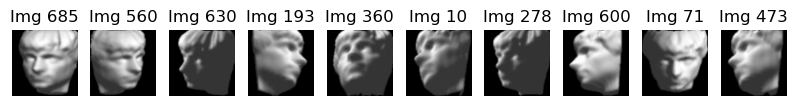

In [2]:
pixels_per_dimension = 64
nOfImgs = face_data.shape[0]
nOfImgs2Display = 10

np.random.seed(0)
img2Display = np.random.randint(0, nOfImgs, size=nOfImgs2Display)

plt.figure(figsize=(10, 2))
for i, imgInd in enumerate(img2Display):
    # print(imgInd)
    plt.subplot(1, nOfImgs2Display, i + 1)
    plt.imshow(face_data[imgInd].reshape(pixels_per_dimension, pixels_per_dimension).T, cmap='gray')
    # (a side note: a transpose by .T is needed because the original images were all orientated horizontally)
    plt.axis('off')  # Hide the axes for clarity
    plt.title(f"Img {imgInd+1}")

plt.show()

### Perform Isomap on the face dataset

In [3]:
iso = manifold.Isomap(n_neighbors=10, n_components=2)

iso.fit(face_data)
manifold_2D = iso.transform(face_data)
# manifold_2D = pd.DataFrame(manifold_2Da, columns=['Component 1', 'Component 2'])

print(f'Shape of manifold_2D: {manifold_2D.shape}\n')

C:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

Shape of manifold_2D: (698, 2)



### Plot the Isomap results

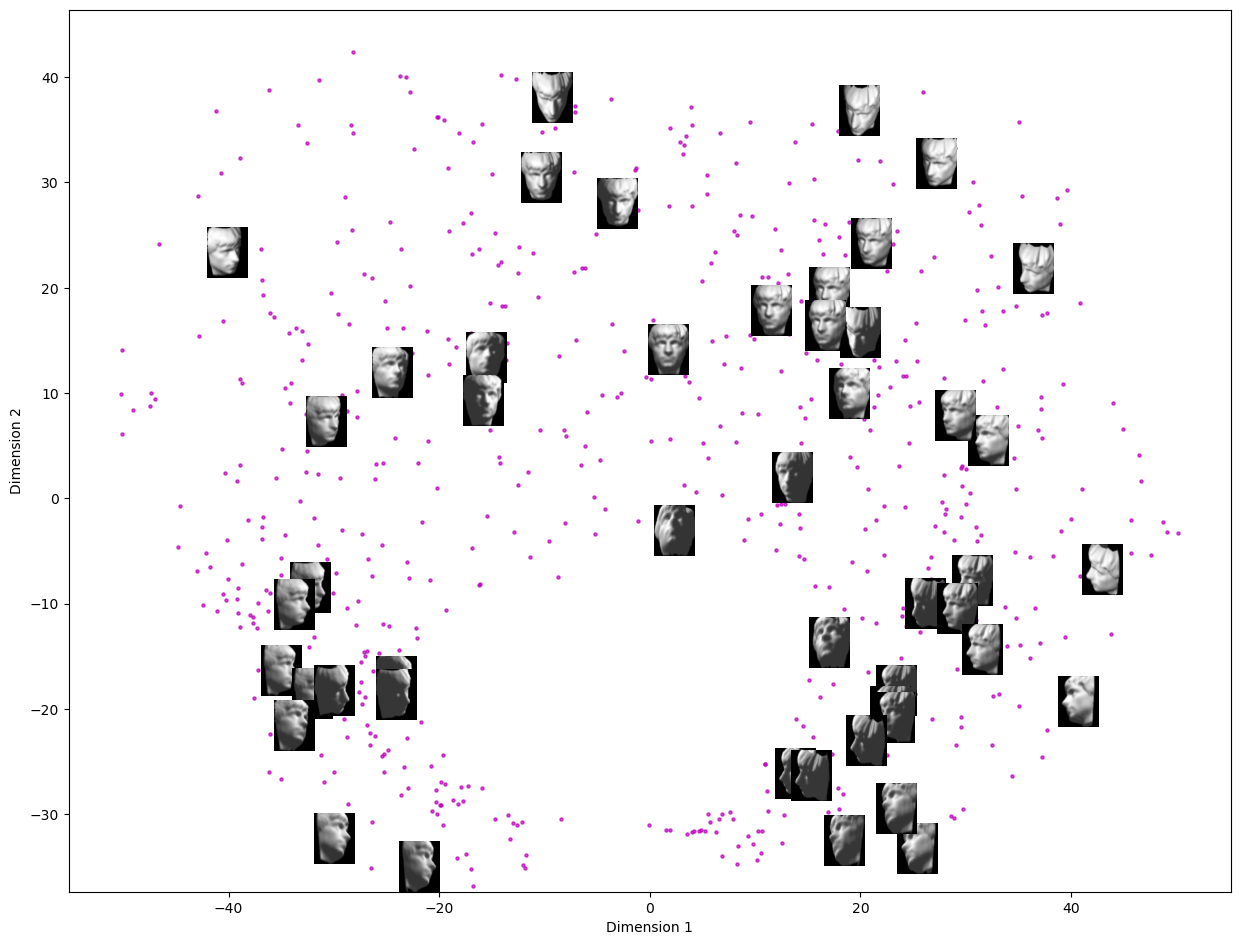

In [4]:
nOfImgs2ShowOn2D = 50

x_size = (max(manifold_2D[0]) - min(manifold_2D[0])) * 0.2
y_size = (max(manifold_2D[1]) - min(manifold_2D[1])) * 0.2

fig = plt.figure()
fig.set_size_inches(15, 15)
ax = fig.add_subplot(111)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')

np.random.seed(0)
for i in range(nOfImgs2ShowOn2D):
    img_num = np.random.randint(0, nOfImgs) # randomly pick an image from the dataset
    x0 = manifold_2D[img_num, 0] - (x_size / 2.)
    y0 = manifold_2D[img_num, 1] - (y_size / 2.)
    x1 = manifold_2D[img_num, 0] + (x_size / 2.)
    y1 = manifold_2D[img_num, 1] + (y_size / 2.)
    img = face_data[img_num,:].reshape(pixels_per_dimension, pixels_per_dimension).T
    ax.imshow(img, aspect='equal', cmap=plt.cm.gray, zorder=100000, extent=(x0, x1, y0, y1))

# Show 2D components plot
ax.scatter(manifold_2D[:,0], manifold_2D[:,1], marker='.',alpha=0.7, s=20, c='m')
# plt.axis('equal')
plt.show()